In [25]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict


In [26]:
class BatsmanState(TypedDict):

    runs: int
    balls: int
    fours: int
    sixes: int

    sr: float
    bpb: float
    boundary_percent: float
    summary: str


In [27]:
graph = StateGraph(BatsmanState)



In [28]:
def calculate_sr(state: BatsmanState):

    sr = (state['runs']/state['balls'])*100
    
    return {'sr': sr}


In [29]:
def calculate_bpb(state: BatsmanState):

    bpb = state['balls']/(state['fours'] + state['sixes'])

    return {'bpb': bpb}


In [30]:
def calculate_boundary_percent(state: BatsmanState):

    boundary_percent = (((state['fours'] * 4) + (state['sixes'] * 6))/state['runs'])*100

    return {'boundary_percent': boundary_percent}


In [31]:
def summary(state: BatsmanState):

    summary = f"""
Strike Rate - {state['sr']} \n
Balls per boundary - {state['bpb']} \n
Boundary percent - {state['boundary_percent']}
"""
    
    return {'summary': summary}


In [32]:
graph.add_node("calculate_sr" , calculate_sr)
graph.add_node("calculate_boundary_percent"  , calculate_boundary_percent)
graph.add_node("calculate_bpb" , calculate_bpb)
graph.add_node("summary" , summary)

graph.set_entry_point("calculate_sr")
graph.set_entry_point("calculate_bpb")
graph.set_entry_point("calculate_boundary_percent")

graph.add_edge("calculate_sr" , "summary")
graph.add_edge("calculate_bpb" , "summary")
graph.add_edge("calculate_boundary_percent" , "summary")

graph.add_edge("summary" , END)

workflow = graph.compile()


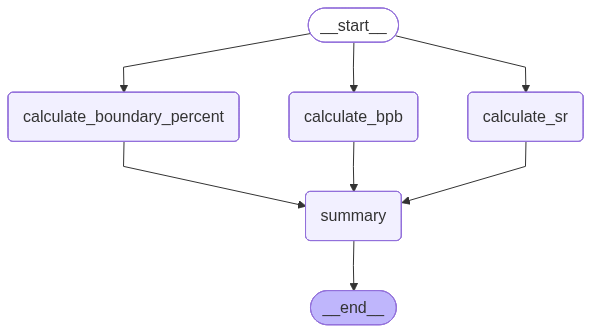

In [33]:
workflow


In [35]:
intial_state = {
    'runs': 100,
    'balls': 50,
    'fours': 6,
    'sixes': 4
}

final_state = workflow.invoke(intial_state)


In [ ]:
print(final_state['summary'])



Strike Rate - 200.0 

Balls per boundary - 5.0 

Boundary percent - 48.0



In [ ]:
final_state


{'runs': 100,
 'balls': 50,
 'fours': 6,
 'sixes': 4,
 'sr': 200.0,
 'bpb': 5.0,
 'boundary_percent': 48.0,
 'summary': '\nStrike Rate - 200.0 \n\nBalls per boundary - 5.0 \n\nBoundary percent - 48.0\n'}